In [5]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [ ]:
data = {
    "text": [
        # Climate / SDG 13
        "satellite monitors climate change",
        "global warming tracked from space",
        "weather prediction using satellite",
        "space data helps disaster management",
        
        # Agriculture / SDG 2
        "satellite improves crop yield",
        "remote sensing for farming",
        "space tech helps agriculture",
        
        # Environment / SDG 15
        "deforestation detected via satellite",
        "forest monitoring from space",
        "wildlife tracking using satellite",
        
        # Innovation / SDG 9
        "new space mission launched",
        "rocket launch successful",
        "satellite development for research",
        "space exploration mission",
        
        # Risk / Negative
        "space debris increasing risk",
        "satellite collision danger",
        "launch failure caused damage",
        "rocket explosion failure"
    ],
    
    "label": [
        "SDG 13","SDG 13","SDG 13","SDG 13",
        "SDG 2","SDG 2","SDG 2",
        "SDG 15","SDG 15","SDG 15",
        "SDG 9","SDG 9","SDG 9","SDG 9",
        "Negative","Negative","Negative","Negative"
    ]
}

df = pd.DataFrame(data)

In [7]:
import re
import pandas as pd

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["text"] = df["text"].apply(clean_text)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create model pipeline
model = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

# Train model
model.fit(df["text"], df["sdg"])

Pipeline(steps=[('vectorizer', TfidfVectorizer()),
                ('classifier', MultinomialNB())])

In [10]:
def predict_with_confidence(text):
    text = clean_text(text)
    probs = model.predict_proba([text])[0]
    classes = model.classes_
    
    result = dict(zip(classes, probs))
    prediction = model.predict([text])[0]
    
    return prediction, result

In [11]:
def extract_keywords(text):
    text = clean_text(text)
    
    vectorizer = model.named_steps['tfidf']
    tfidf_matrix = vectorizer.transform([text])
    feature_names = vectorizer.get_feature_names_out()
    
    scores = tfidf_matrix.toarray()[0]
    
    keywords = sorted(
        [(feature_names[i], scores[i]) for i in range(len(scores))],
        key=lambda x: x[1],
        reverse=True
    )
    
    return [word for word, score in keywords[:3]]

In [12]:
def impact_type(text):
    text = text.lower()
    
    positive_words = ["help", "improve", "monitor", "support"]
    negative_words = ["risk", "damage", "failure", "debris", "explosion"]
    
    for word in negative_words:
        if word in text:
            return "Negative ❌"
    
    for word in positive_words:
        if word in text:
            return "Positive ✅"
    
    return "Neutral ⚪"

In [13]:
def generate_insight(pred):
    insights = {
        "SDG 13": "Supports climate monitoring and disaster prevention",
        "SDG 2": "Improves agriculture and food security",
        "SDG 15": "Helps protect forests and biodiversity",
        "SDG 9": "Promotes innovation and space technology development",
        "Negative": "Indicates environmental or technological risk"
    }
    
    return insights.get(pred, "No insight available")

In [14]:
def smart_predict(text):
    pred, probs = predict_with_confidence(text)
    confidence = max(probs.values())
    
    if confidence < 0.5:
        return "Unknown", confidence, probs
    
    return pred, confidence, probs

In [15]:
def rule_based_boost(text):
    text = text.lower()
    
    if "mission" in text or "launch" in text:
        return "SDG 9"
    if "climate" in text or "weather" in text:
        return "SDG 13"
    if "crop" in text or "agriculture" in text:
        return "SDG 2"
    
    return None

In [28]:
import re

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r"[^a-z\s]", "", text)
        return text
    return ""

def rule_based_boost(text):
    text = text.lower()
    if "climate" in text or "global warming" in text:
        return "SDG 13"
    elif "crop" in text or "agriculture" in text:
        return "SDG 2"
    return None

def smart_predict(text):
    text = clean_text(text)
    probs = model.predict_proba([text])[0]
    pred = model.predict([text])[0]
    confidence = max(probs)
    return pred, confidence, probs

def extract_keywords(text):
    text = clean_text(text)
    vectorizer = model.named_steps['vectorizer']
    tfidf_matrix = vectorizer.transform([text])
    feature_names = vectorizer.get_feature_names_out()
    scores = tfidf_matrix.toarray()[0]
    top_indices = scores.argsort()[-5:][::-1]
    keywords = [feature_names[i] for i in top_indices if scores[i] > 0]
    return keywords

def impact_type(text):
    text = text.lower()
    if "improve" in text or "help" in text:
        return "Positive"
    elif "damage" in text or "pollution" in text:
        return "Negative"
    return "Neutral"

def generate_insight(pred):
    return f"This statement is related to {pred} and highlights its global importance."

text = input("Enter space-related statement: ")

rule = rule_based_boost(text)

if rule:
    pred = rule
    confidence = 1.0
else:
    pred, confidence, probs = smart_predict(text)

keywords = extract_keywords(text)
impact = impact_type(text)
insight = generate_insight(pred)

print("\n🌍 SDG:", pred)
print("📊 Confidence:", round(confidence, 2))
print("🔑 Keywords:", keywords)
print("🌗 Impact:", impact)
print("🚀 Insight:", insight)


🌍 SDG: SDG 2
📊 Confidence: 0.31
🔑 Keywords: ['farming', 'remote', 'sensing', 'for']
🌗 Impact: Neutral
🚀 Insight: This statement is related to SDG 2 and highlights its global importance.


In [21]:
import matplotlib.pyplot as plt

def plot_confidence(probs):
    labels = model.classes_
    values = probs

    plt.figure()
    plt.bar(labels, values)
    plt.xlabel("SDG Classes")
    plt.ylabel("Confidence")
    plt.title("Prediction Confidence")
    plt.xticks(rotation=45)
    plt.show()

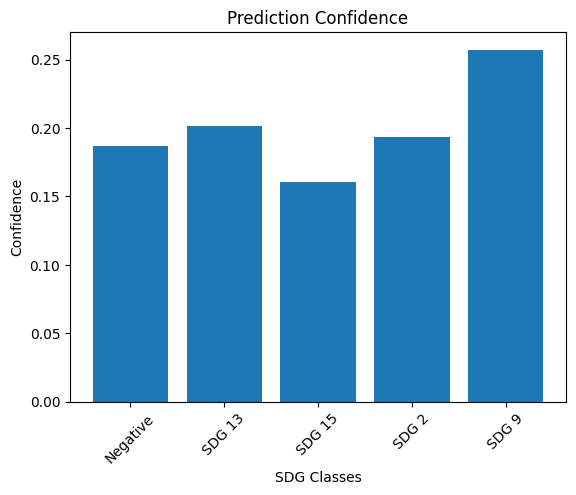

In [22]:
plot_confidence(probs)

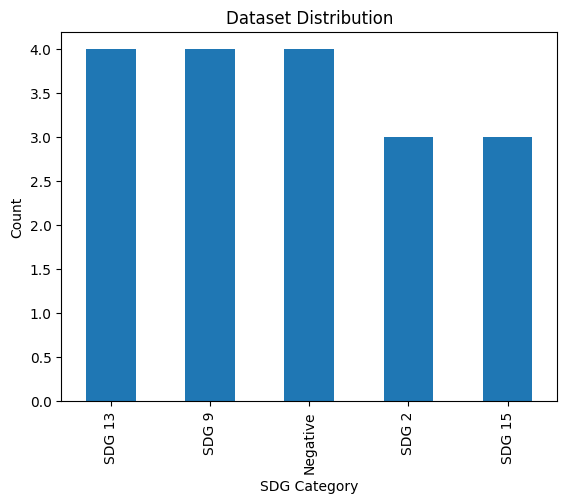

In [23]:
df["sdg"].value_counts().plot(kind="bar")
plt.title("Dataset Distribution")
plt.xlabel("SDG Category")
plt.ylabel("Count")
plt.show()